# Module 2: Epidemic Modeling Template

## Team Members:
Aryan Mhaskar and Lauren McElfresh

## Project Title:
*Evolution and Identification of a Viral Outbreak and Vaccine Campaign vs Rollout Comparison*

## Project Goal:
This project seeks to:
* Model disease progression over time. 
* Intervention: Vaccination campaign
* Intervention: Vaccination rollout

## 1. Data and disease background (Lauren)
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence (UVA population): 
    * 613 active cases on day 120
* Incidence (UVA population): 
    * By day 45, the incidence is 29.3 new cases per day
* Economic burden (you can generalize from respiratory viruses):
    *   ------------------------------------------------------------------
* Symptoms:
    * Mild respiratory symptoms
    * Rash
    * Low-grade fever
    * Sore throat
    * Fatigue
    * Gastrointensinal symptoms (in ~8% of patients)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)
    * This respiratory virus is transmitted via respiratory droplets through mechanisms like coughing. When inhailed or if the virus comes into contact with the mouth, nose, or eyes, it could spread and cause infection. 
    * The upper airways like the nasal cavity, nasopharynx, and oropharynx, which have a mucus‑secreting lining, is what the virus first comes into contact with. Once the virus has infected the host, it will continue to replicate in the nose, throat, and bronchi. 
    * The host's immune system will detect the virus and activate inflammatory cytokines that cause symptoms like congestion, sore throat, cough, and fever.


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods (Aryan)

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



# Before Everything: Import all Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45) 
This section should come from your python code after Data Release #1.

Estimated R0: 0.12


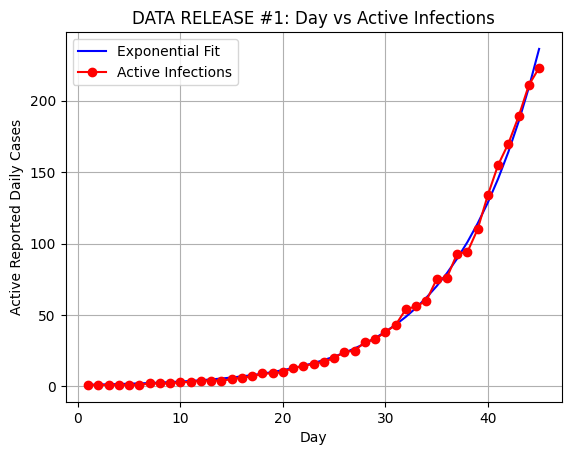

In [2]:

# Load the data
data = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
popt, pcov = curve_fit(exponential_growth, data['day'], data['active reported daily cases'])
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.

# Approximate R0 using this fit
r = popt[0]
print(f"Estimated R0: {r:.2f}")

# Add the fit as a line on top of our scatterplot.

plt.plot(data['day'], exponential_growth(data['day'], r), color='blue', label='Exponential Fit')
plt.plot(data['day'], data['active reported daily cases'], marker='o', color='red', label='Active Infections')

plt.title('DATA RELEASE #1: Day vs Active Infections')
plt.xlabel('Day')
plt.ylabel('Active Reported Daily Cases')
plt.legend()
plt.grid(True)

plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model. (Aryan can split up the code into the different boxes)
This section should come from your python code after Data Release #2.

In [3]:
# We are defining the function below to correspond to the pseudocode in the lecture 3 powerpoint for the module. 
# INPUTS: beta, sigma, gamma, S0, E0, I0, R0, timepoints, N
def seir_euler(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):

    # time step
    dt = timepoints[1] - timepoints[0]

    # Initialize S, E, I, and R as empty arrays or lists
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    # Set first item in each list equal to initial values S0, E0, I0, R0
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    # For each timepoint in timepoints:
    for t in range(len(timepoints) - 1):

        # Calculate the four derivatives at timepoint
        dSdt = -beta * S[t] * I[t] / N
        dEdt = beta * S[t] * I[t] / N - sigma * E[t]
        dIdt = sigma * E[t] - gamma * I[t]
        dRdt = gamma * I[t]

        # Calculate S, E, I, and R at timepoint + 1 using Euler’s method
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt

    # Return S, E, I, and R
    return S, E, I, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [4]:
# Defining our starting parameters to be updated later with the grid search. 
N       = 20_000   # assumed total population
I0      = 1
E0      = 0
R0_init = 0
S0      = N - I0 - E0 - R0_init

# Load data 
df = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#2.csv')
data_days = df['day'].values
data_I    = df['active reported daily cases'].values

timepoints = np.arange(1, data_days[-1] + 1, 1)  # one timepoint per day

# Grid search
best_SSE    = np.inf
best_params = None

for beta in np.arange(0.40, 0.65, 0.01):
    for sigma in np.arange(0.30, 0.50, 0.01):
        for gamma in np.arange(0.15, 0.30, 0.01):

            S, E, I, R = seir_euler(beta, sigma, gamma,
                                    S0, E0, I0, R0_init,
                                    timepoints, N)

            # Compare model I(t) to observed data at matching days
            model_I_at_data = I[data_days - 1]   # data_days are 1-indexed
            SSE = np.sum((model_I_at_data - data_I) ** 2)

            if SSE < best_SSE:
                best_SSE    = SSE
                best_params = (beta, sigma, gamma)

beta, sigma, gamma = best_params
print(f"Best-fit parameters:")
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ≈ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ≈ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")

# Run model with best params
t_extended = np.arange(1, 201, 1)
S, E, I, R = seir_euler(beta, sigma, gamma, S0, E0, I0, R0_init, t_extended, N)

Best-fit parameters:
  beta  = 0.490
  sigma = 0.410  (incubation period ≈ 2.4 days)
  gamma = 0.220  (infectious period ≈ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

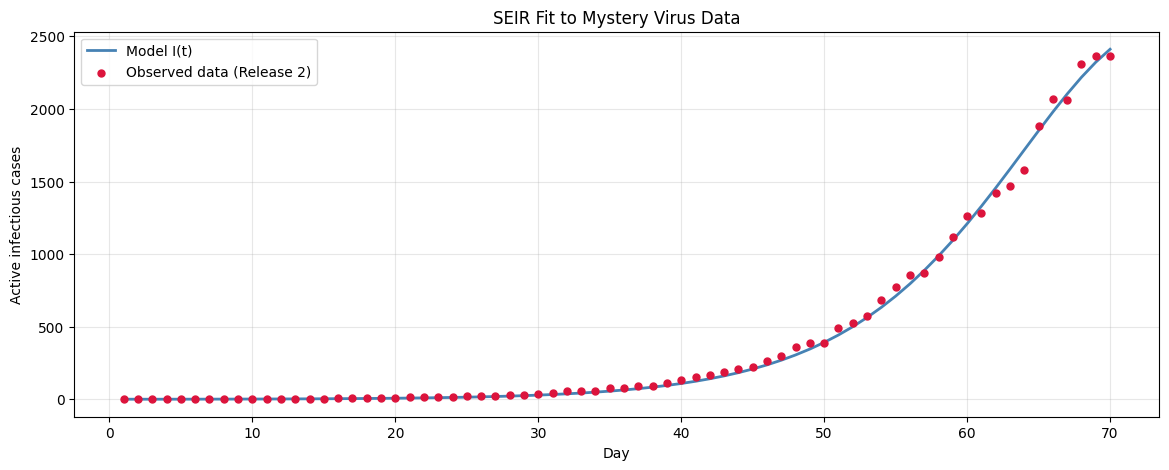

  beta  = 0.490
  sigma = 0.410  (incubation period ≈ 2.4 days)
  gamma = 0.220  (infectious period ≈ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2


In [5]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Model vs data over the data window
ax = axes
ax.plot(t_extended[:data_days[-1]], I[:data_days[-1]],
        color='steelblue', linewidth=2, label='Model I(t)')
ax.scatter(data_days, data_I,
           color='crimson', s=25, zorder=5, label='Observed data (Release 2)')
ax.set_xlabel('Day')
ax.set_ylabel('Active infectious cases')
ax.set_title('SEIR Fit to Mystery Virus Data')
ax.legend()
ax.grid(alpha=0.3)

plt.show()
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ≈ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ≈ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [6]:
# Find the max value on our predicted curve
model_peak_val = np.max(I)
model_peak_day = t_extended[np.argmax(I)] #Find what day corresponds to the max value on the predicted curve. 
print(f"Model peak: {model_peak_val:.1f} cases on day {model_peak_day:.0f}")

Model peak: 2574.8 cases on day 74



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


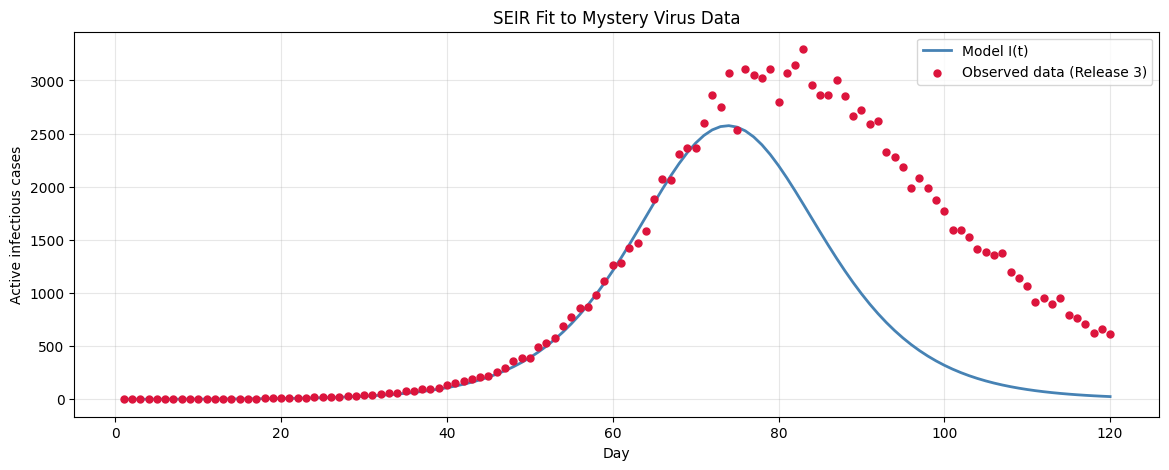

  beta  = 0.490
  sigma = 0.410  (incubation period ≈ 2.4 days)
  gamma = 0.220  (infectious period ≈ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2


In [7]:
# Load full dataset (Release 3, days 1-120)
df = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#3.csv')
data_days = df['day'].values
data_I    = df['active reported daily cases'].values

# Plot
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Model vs data over the data window
ax = axes
ax.plot(t_extended[:data_days[-1]], I[:data_days[-1]],
        color='steelblue', linewidth=2, label='Model I(t)')
ax.scatter(data_days, data_I,
           color='crimson', s=25, zorder=5, label='Observed data (Release 3)')
ax.set_xlabel('Day')
ax.set_ylabel('Active infectious cases')
ax.set_title('SEIR Fit to Mystery Virus Data')
ax.legend()
ax.grid(alpha=0.3)

plt.show()
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ≈ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ≈ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")

### 2g. Intervention strategies for new outbreak at VT (70 days of infection) (Lauren: Vaccine Campaign, Aryan: Vaccine Rollout)
This section should come from your python code after Data Release #3.



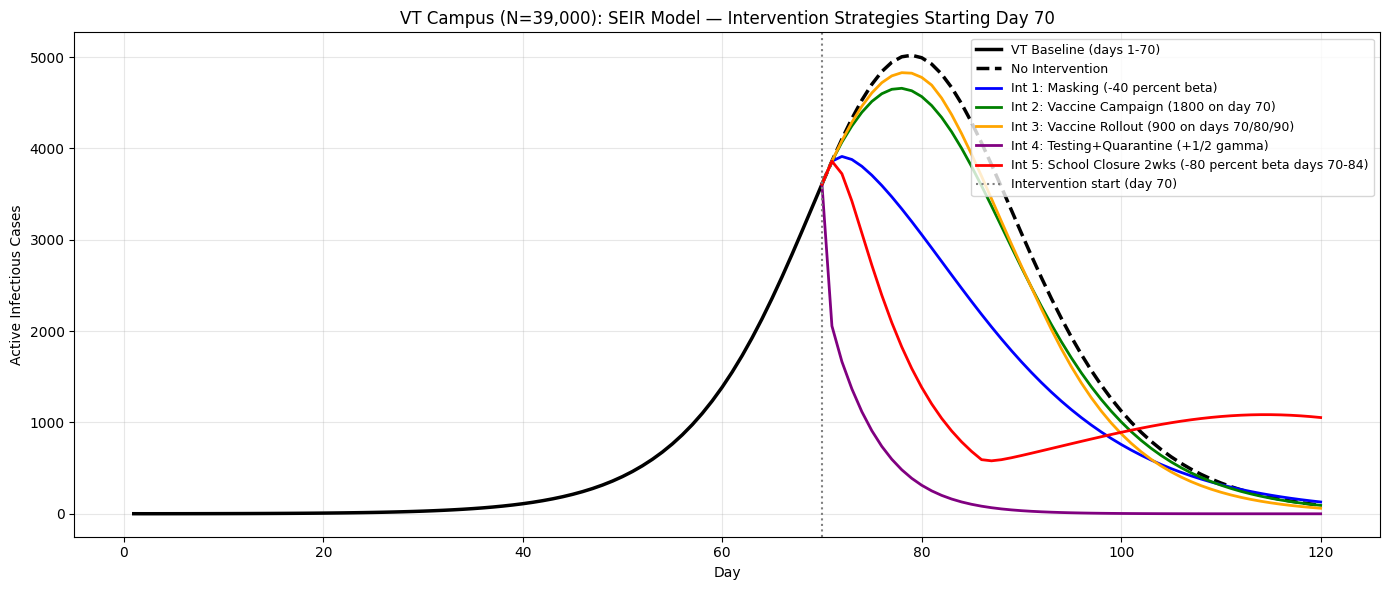

Intervention                          Peak I   Peak Day   I at Day 120  Cases Prevented
-------------------------------------------------------------------------------------
No Intervention                       5020.6         79           94.9              0.0
Int 1: Masking                        3912.7         72          129.4          37735.1
Int 2: Vaccine Campaign               4658.8         78           92.1           9520.1
Int 3: Vaccine Rollout                4829.9         78           60.8           9677.3
Int 4: Testing+Quarantine             3608.9         70            0.0         103424.5
Int 5: School Closure 2wks            3860.9         71         1053.9          52043.1


In [ ]:
# VT has a larger campus than UVA; same disease parameters (beta, sigma, gamma from 2d)
# but different initial conditions. E0_VT matches UVA's E0 at t=0.
N_VT    = 39_000  # VT student population
I0_VT   = 1
R0_VT   = 0
E0_VT   = E0      # same as UVA's E0 (defined in cell 2d)
S0_VT   = N_VT - I0_VT - E0_VT - R0_VT

# Run VT baseline SEIR for 70 days using the UVA best-fit parameters
t_vt_pre = np.arange(1, 71, 1)  # days 1-70
S_vt_pre, E_vt_pre, I_vt_pre, R_vt_pre = seir_euler(
    beta, sigma, gamma, S0_VT, E0_VT, I0_VT, R0_VT, t_vt_pre, N_VT)

# State at end of day 70 (last element of pre-intervention run)
S70 = S_vt_pre[-1]
E70 = E_vt_pre[-1]
I70 = I_vt_pre[-1]
R70 = R_vt_pre[-1]

t_intervention = np.arange(70, 121, 1)  # days 70-120

# Run SEIR from day 70 onward with a time-varying beta function
def seir_euler_intervention(beta_func, sigma, gamma, S70, E70, I70, R70, timepoints, N):
    dt = timepoints[1] - timepoints[0]
    n = len(timepoints)
    S = np.zeros(n); E = np.zeros(n); I = np.zeros(n); R = np.zeros(n)
    S[0] = S70; E[0] = E70; I[0] = I70; R[0] = R70
    for t in range(n - 1):
        b = beta_func(timepoints[t])
        dSdt = -b * S[t] * I[t] / N
        dEdt =  b * S[t] * I[t] / N - sigma * E[t]
        dIdt =  sigma * E[t] - gamma * I[t]
        dRdt =  gamma * I[t]
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt
    return S, E, I, R

#  Baseline (no intervention, days 70-120)
S_no_int, E_no_int, I_no_int, R_no_int = seir_euler_intervention(
    lambda day: beta, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# Intervention 1: Masking mandates (reduce beta by 40%)
S_int1, E_int1, I_int1, R_int1 = seir_euler_intervention(
    lambda day: beta * 0.60, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# Intervention 2: Vaccine Campaign (move 1800 from S to R on day 70)
S70_v2 = max(S70 - 1800, 0)
R70_v2 = R70 + (S70 - S70_v2)
S_int2, E_int2, I_int2, R_int2 = seir_euler_intervention(
    lambda day: beta, sigma, gamma, S70_v2, E70, I70, R70_v2, t_intervention, N_VT)

# Intervention 3: Vaccine Rollout (900 vaccinated on days 70, 80, 90) 
def seir_euler_rollout(beta, sigma, gamma, S70, E70, I70, R70, timepoints, N, vax_days, vax_amount):
    dt = timepoints[1] - timepoints[0]
    n = len(timepoints)
    S = np.zeros(n); E = np.zeros(n); I = np.zeros(n); R = np.zeros(n)
    S[0] = S70; E[0] = E70; I[0] = I70; R[0] = R70
    for t in range(n - 1):
        if timepoints[t] in vax_days:
            vax = min(vax_amount, S[t])
            S[t] -= vax
            R[t] += vax
        dSdt = -beta * S[t] * I[t] / N
        dEdt =  beta * S[t] * I[t] / N - sigma * E[t]
        dIdt =  sigma * E[t] - gamma * I[t]
        dRdt =  gamma * I[t]
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt
    return S, E, I, R

S_int3, E_int3, I_int3, R_int3 = seir_euler_rollout(
    beta, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT,
    vax_days=[70, 80, 90], vax_amount=900)

# Intervention 4: Testing + quarantine (increase gamma by 1/2)
gamma_int4 = gamma + 1/2
S_int4, E_int4, I_int4, R_int4 = seir_euler_intervention(
    lambda day: beta, sigma, gamma_int4, S70, E70, I70, R70, t_intervention, N_VT)

# Intervention 5: School closure for 2 weeks (days 70-84, beta reduced 80%)
def beta_closure(day):
    if 70 <= day <= 84:
        return beta * 0.20
    return beta

S_int5, E_int5, I_int5, R_int5 = seir_euler_intervention(
    beta_closure, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# Plot: pre-intervention VT curve + all 5 interventions from day 70 
fig, ax = plt.subplots(figsize=(14, 6))

# Pre-intervention (days 1-70)
ax.plot(t_vt_pre, I_vt_pre, color='black', linewidth=2.5, label='VT Baseline (days 1-70)')

# Post-day-70 curves
ax.plot(t_intervention, I_no_int, color='black', linewidth=2.5, linestyle='--', label='No Intervention')
ax.plot(t_intervention, I_int1,   color='blue', linewidth=2,   label='Int 1: Masking (-40 percent beta)')
ax.plot(t_intervention, I_int2,   color='green', linewidth=2,   label='Int 2: Vaccine Campaign (1800 on day 70)')
ax.plot(t_intervention, I_int3,   color='orange', linewidth=2,   label='Int 3: Vaccine Rollout (900 on days 70/80/90)')
ax.plot(t_intervention, I_int4,   color='purple', linewidth=2,   label='Int 4: Testing+Quarantine (+1/2 gamma)')
ax.plot(t_intervention, I_int5,   color='red', linewidth=2,   label='Int 5: School Closure 2wks (-80 percent beta days 70-84)')

ax.axvline(x=70, color='gray', linestyle=':', linewidth=1.5, label='Intervention start (day 70)')
ax.set_xlabel('Day')
ax.set_ylabel('Active Infectious Cases')
ax.set_title(f'VT Campus (N={N_VT:,}): SEIR Model — Intervention Strategies Starting Day 70')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary Table ---
interventions = {
    'No Intervention':             I_no_int,
    'Int 1: Masking':              I_int1,
    'Int 2: Vaccine Campaign':     I_int2,
    'Int 3: Vaccine Rollout':      I_int3,
    'Int 4: Testing+Quarantine':   I_int4,
    'Int 5: School Closure 2wks':  I_int5,
}

print(f"{'Intervention':<35} {'Peak I':>8} {'Peak Day':>10} {'I at Day 120':>14} {'Cases Prevented':>16}")
print('-' * 85)
total_no_int = np.sum(I_no_int)
for name, I_arr in interventions.items():
    peak_val  = np.max(I_arr) # Grab the largest value in the set
    peak_day  = t_intervention[np.argmax(I_arr)] # Find the index corresponding to the largest value and then grab which day it was
    val_120   = I_arr[-1] 
    prevented = total_no_int - np.sum(I_arr)
    print(f"{name:<35} {peak_val:>8.1f} {peak_day:>10.0f} {val_120:>14.1f} {prevented:>16.1f}")


## Verify and validate your analysis: (Aryan)

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: (Lauren)
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: (Aryan)
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*